# https://www.kaggle.com/datasets/uditjain13/credit-card-fraud-detection-2026/data

# IMPORT IMPORTANT LIBRARY


In [1]:

import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv


# LOADING THE DATASET

In [2]:
df=pd.read_csv("/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv")

# STATISTICAL ANALYSIS

In [3]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [5]:
df.shape

(20000, 26)

In [6]:
df.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [7]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

transaction_id                  20000
amount_usd                      12782
merchant_category                  12
card_type                           5
auth_method                         5
channel                             5
device_type                         8
is_foreign_transaction              2
hours_since_last_txn             3296
txn_count_last_24h                 13
distance_from_home_km            6121
card_age_months                    52
customer_age                       64
account_balance_usd             19629
is_new_merchant                     2
used_vpn                            2
ip_country_mismatch                 2
billing_shipping_mismatch           2
cvv_retry_count                     4
velocity_score                    634
time_of_day_hour                   24
day_of_week                         7
is_ai_generated_scam_attempt        2
merchant_risk_score               940
prior_disputes                      5
is_fraud                            2
dtype: int64

# EDA

## import visualization library

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## Distribution of important columns

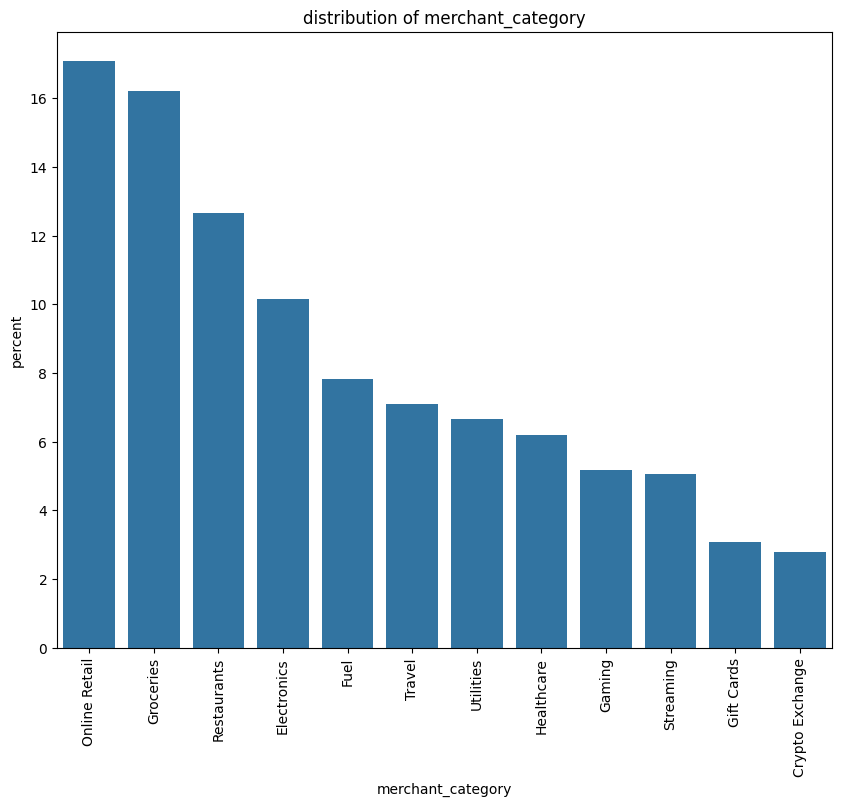

In [11]:
vc=df['merchant_category'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(10,8))
sns.barplot(x=vc.index,y=vc.values)
plt.title("distribution of merchant_category")
plt.ylabel("percent")
plt.xticks(rotation=90)
plt.show()

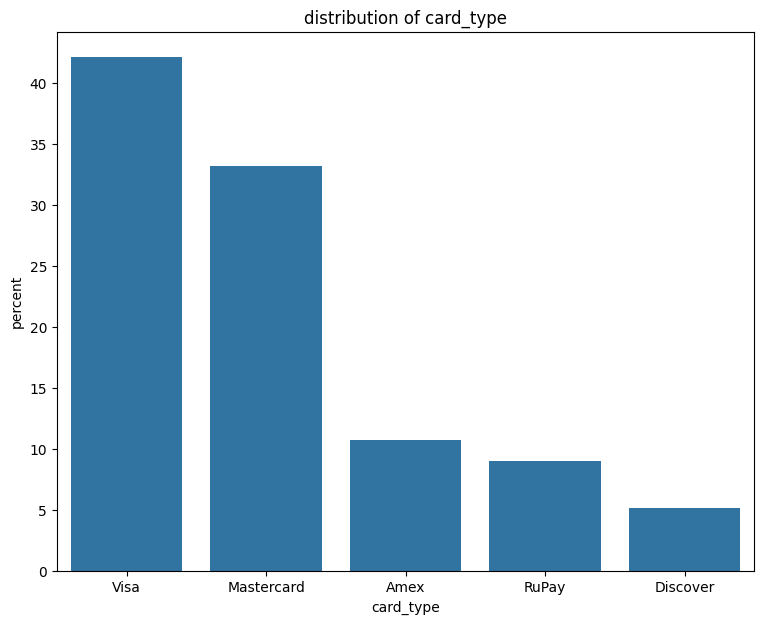

In [12]:
v=df['card_type'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(9,7))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of card_type")
plt.ylabel("percent")
plt.show()

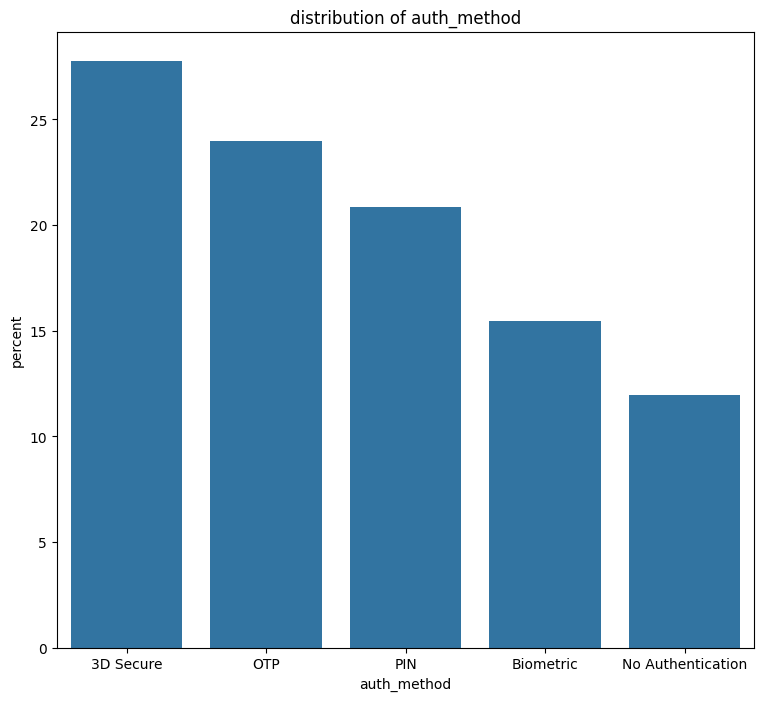

In [13]:
v=df['auth_method'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(9,8))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of auth_method")
plt.ylabel("percent")
plt.show()

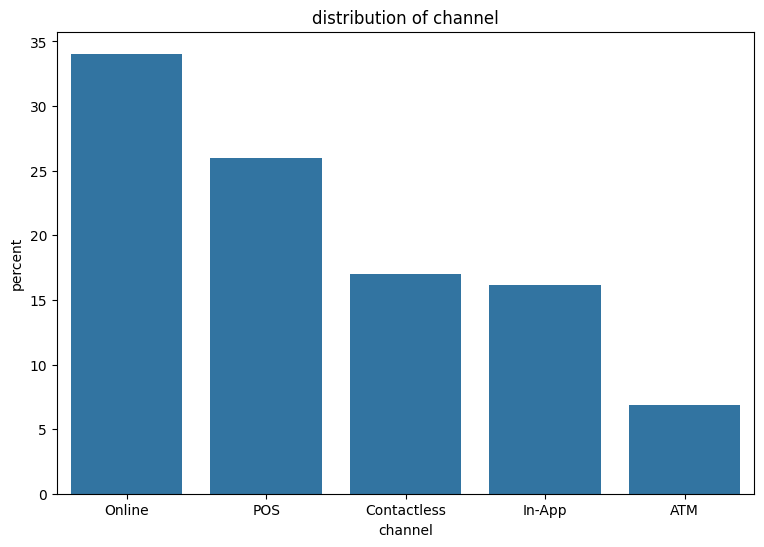

In [14]:
v=df['channel'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(9,6))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of channel")
plt.ylabel("percent")
plt.show()

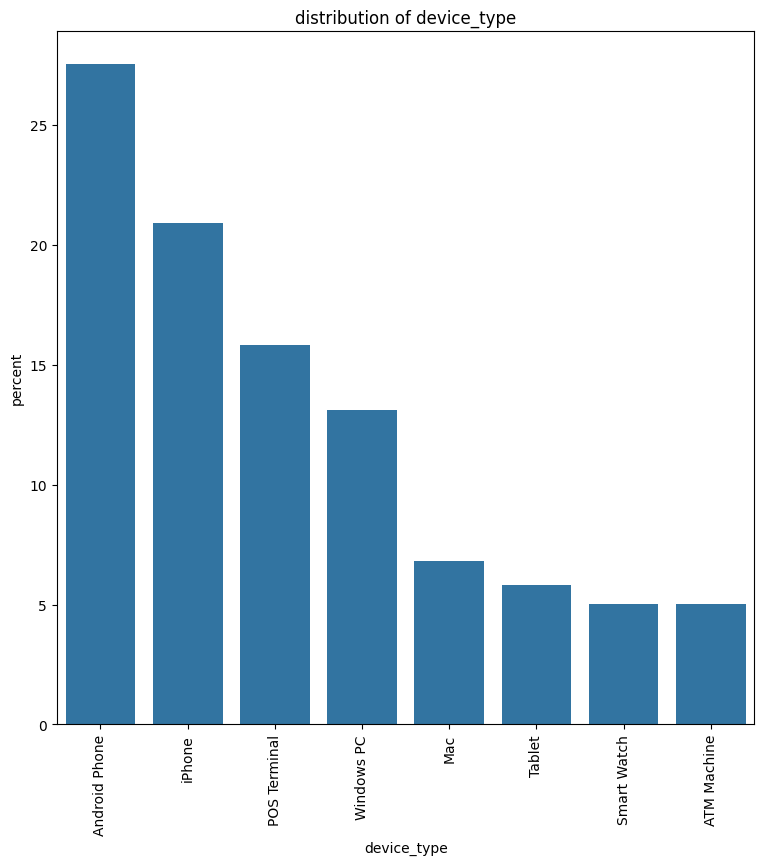

In [15]:
v=df['device_type'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(9,9))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of device_type")
plt.ylabel("percent")
plt.xticks(rotation=90)
plt.show()

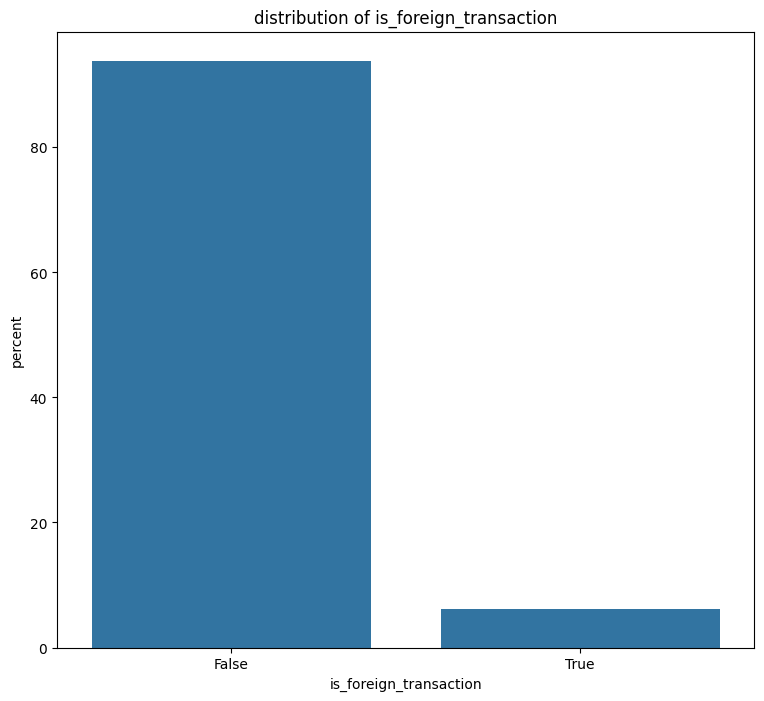

In [16]:
v=df['is_foreign_transaction'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(9,8))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of is_foreign_transaction")
plt.ylabel("percent")
plt.show()

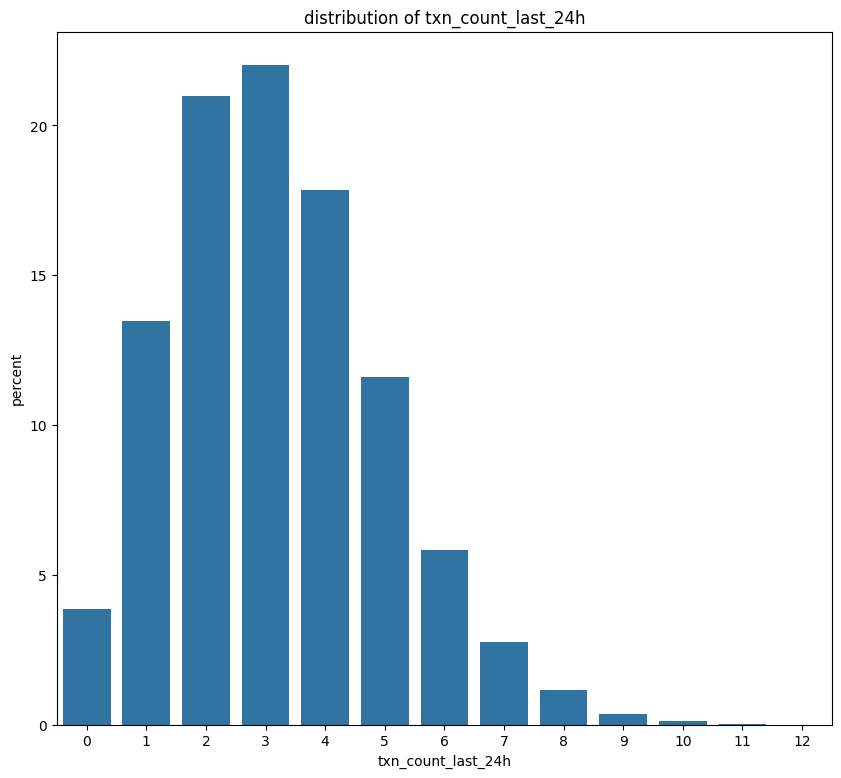

In [17]:
v=df['txn_count_last_24h'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(10,9))
sns.barplot(x=v.index,y=v.values)

plt.title("distribution of txn_count_last_24h")
plt.ylabel("percent")
plt.show()

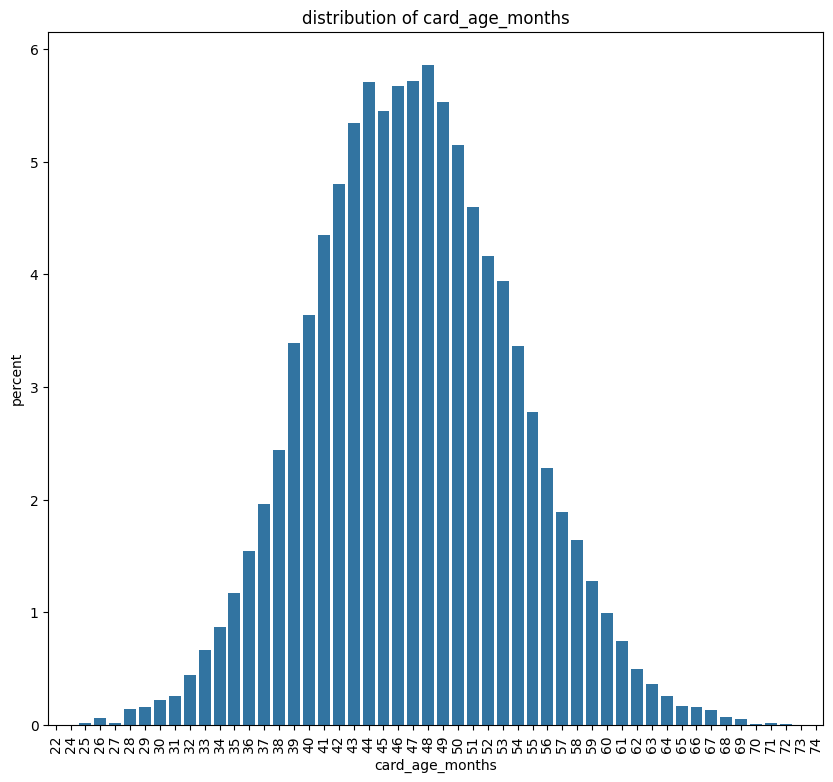

In [18]:
v=df['card_age_months'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(10,9))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of card_age_months")
plt.ylabel("percent")
plt.xticks(rotation=90)
plt.show()

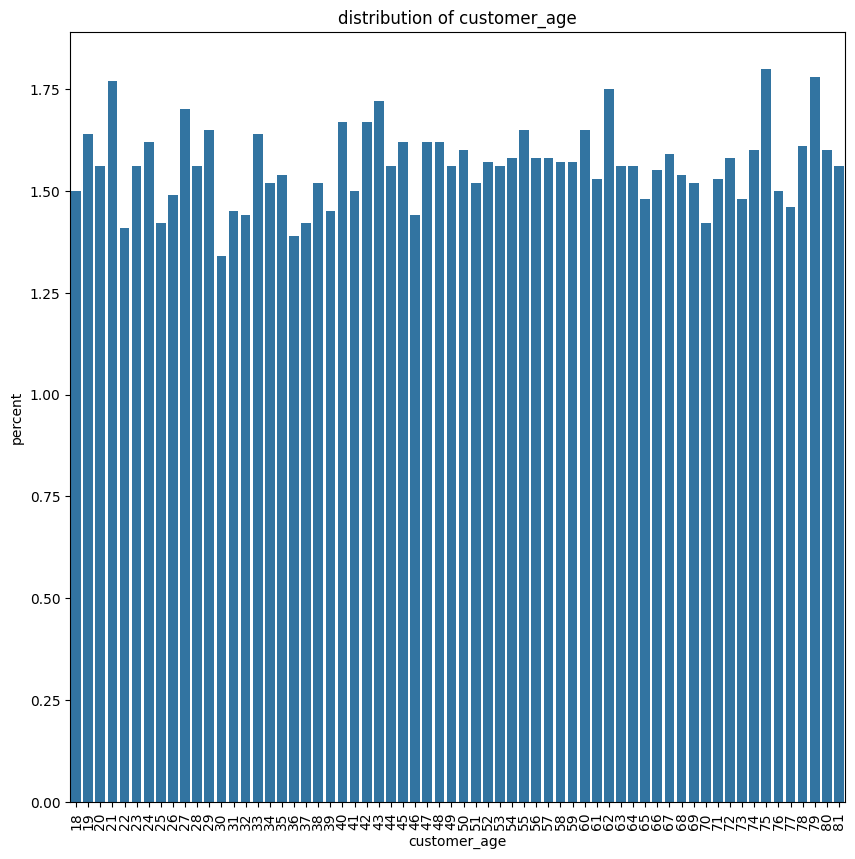

In [19]:
v=df['customer_age'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(10,10))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of customer_age")
plt.ylabel("percent")
plt.xticks(rotation=90)
plt.show()

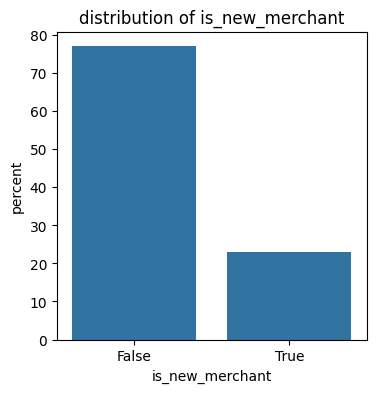

In [20]:
v=df['is_new_merchant'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(4,4))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of is_new_merchant")
plt.ylabel("percent")
plt.show()

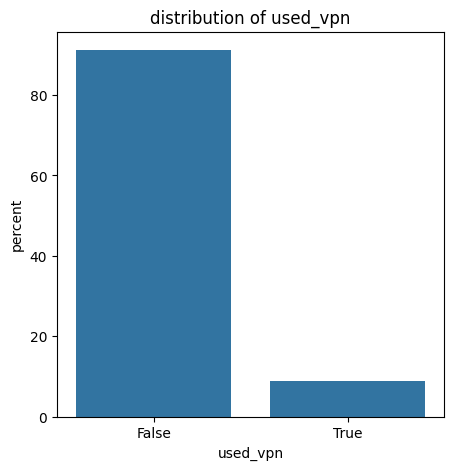

In [21]:
v=df['used_vpn'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of used_vpn")
plt.ylabel("percent")
plt.show()

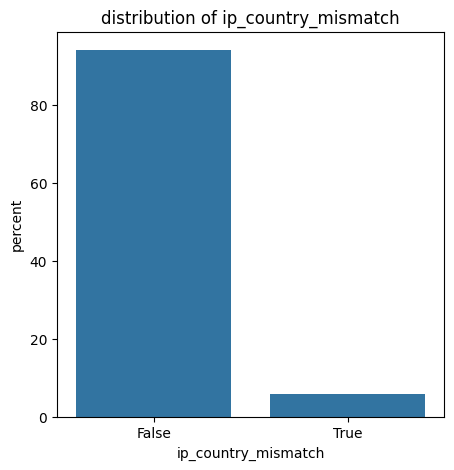

In [22]:
v=df['ip_country_mismatch'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of ip_country_mismatch")
plt.ylabel("percent")
plt.show()

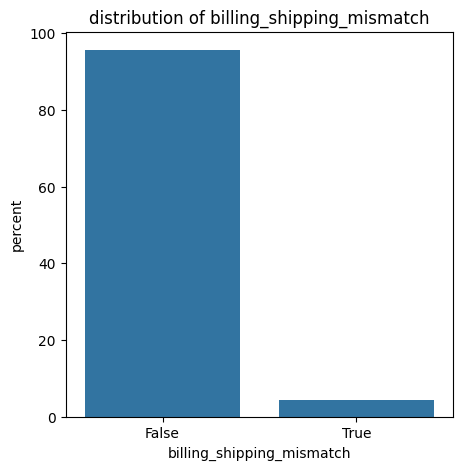

In [23]:
v=df['billing_shipping_mismatch'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of billing_shipping_mismatch")
plt.ylabel("percent")
plt.show()

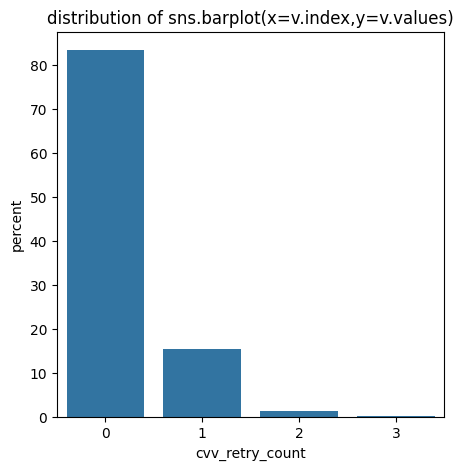

In [24]:
v=df['cvv_retry_count'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of sns.barplot(x=v.index,y=v.values)")
plt.ylabel("percent")
plt.show()

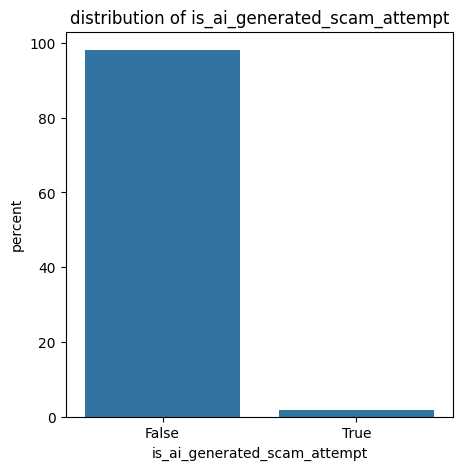

In [25]:
v=df['is_ai_generated_scam_attempt'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of is_ai_generated_scam_attempt")
plt.ylabel("percent")
plt.show()

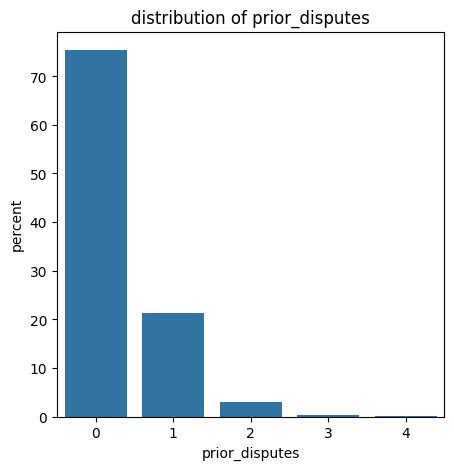

In [26]:
v=df['prior_disputes'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of prior_disputes")
plt.ylabel("percent")
plt.show()

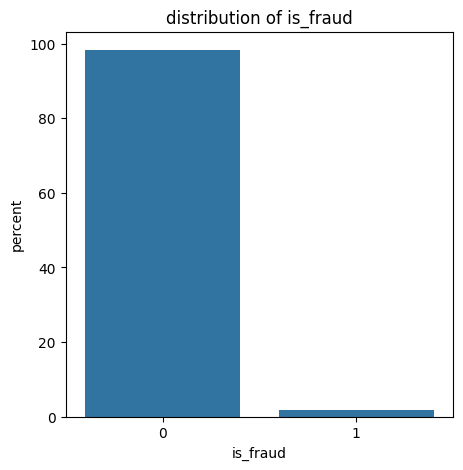

In [27]:
v=df['is_fraud'].value_counts(normalize=True).mul(100).round(2)
plt.figure(figsize=(5,5))
sns.barplot(x=v.index,y=v.values)
plt.title("distribution of is_fraud")
plt.ylabel("percent")
plt.show()

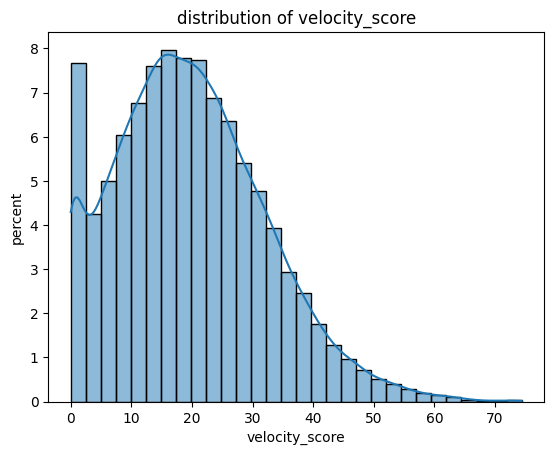

In [28]:
sns.histplot(df['velocity_score'],bins=30,stat="percent",kde=True)
plt.title("distribution of velocity_score")
plt.ylabel("percent")
plt.show()

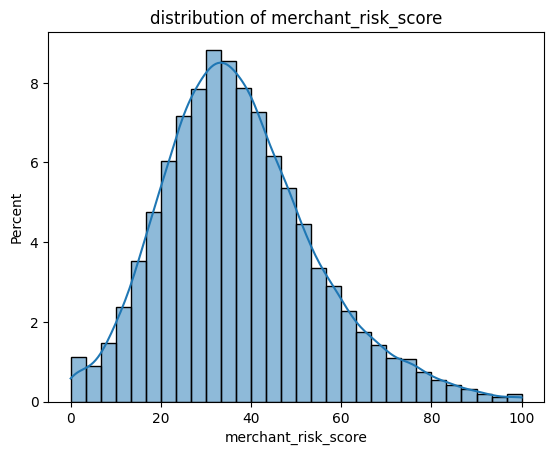

In [29]:
sns.histplot(df['merchant_risk_score'],bins=30,stat="percent",kde=True)
plt.title("distribution of merchant_risk_score")
plt.show()

## relation between heigh risk columns with terget

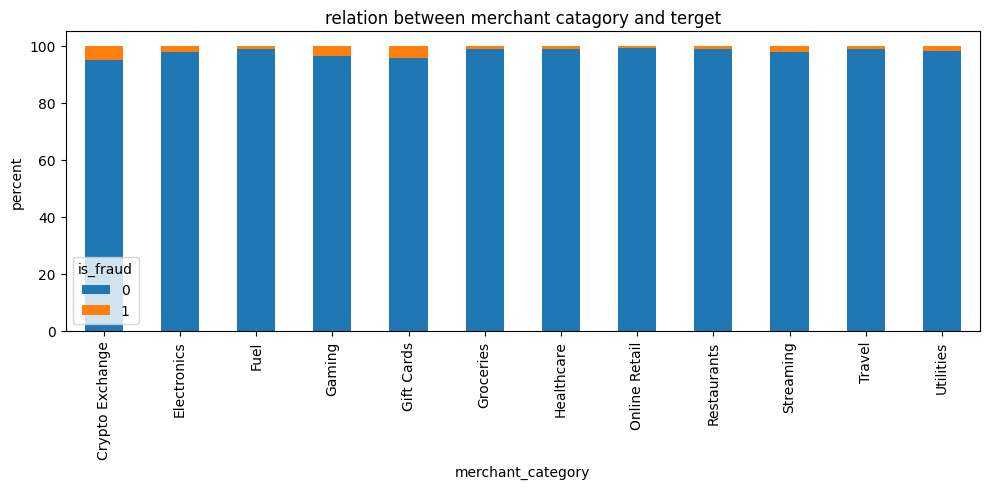

In [30]:
c=pd.crosstab(df['merchant_category'],df['is_fraud'],normalize="index")
p=c.mul(100).plot(kind="bar",stacked=True,figsize=(10,5))

plt.title("relation between merchant catagory and terget")
plt.xticks(rotation=90)
plt.ylabel("percent")
plt.tight_layout()
plt.show()

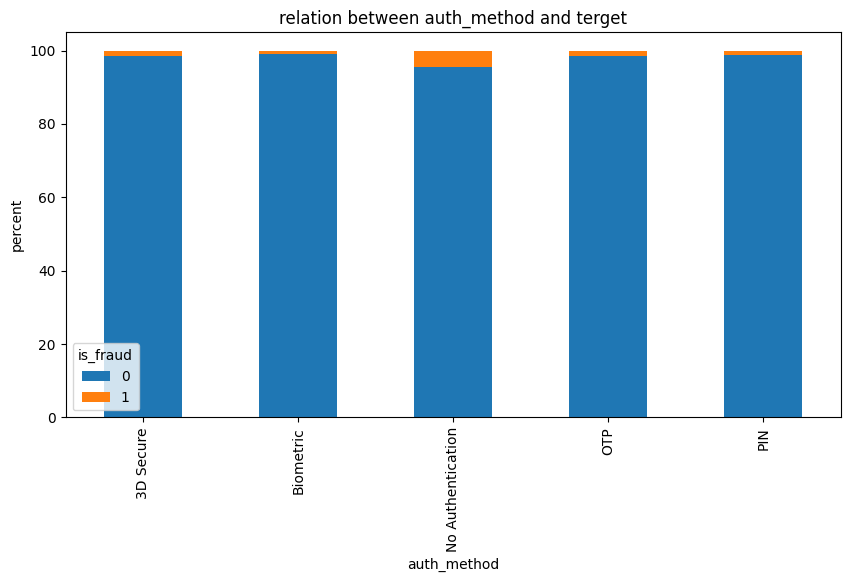

In [31]:
c=pd.crosstab(df['auth_method'],df['is_fraud'],normalize="index")
p=c.mul(100).plot(kind="bar",stacked=True,figsize=(10,5))
plt.title("relation between auth_method and terget")
plt.ylabel("percent")
plt.show()

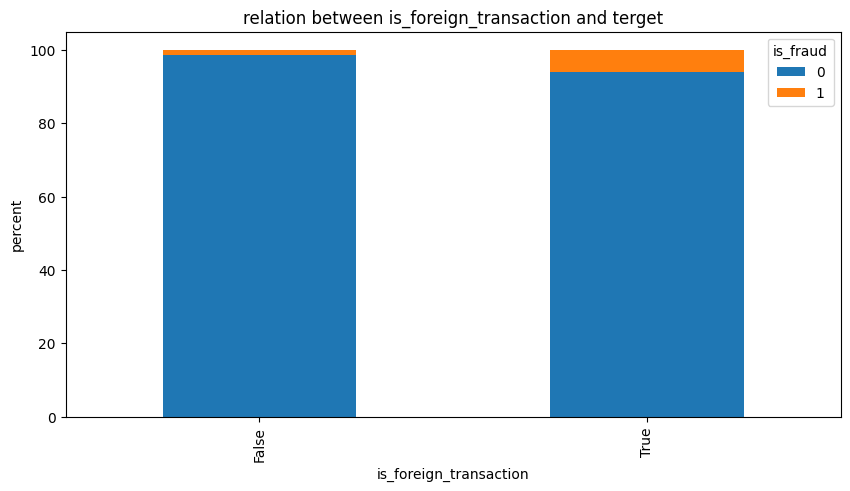

In [32]:
c=pd.crosstab(df['is_foreign_transaction'],df['is_fraud'],normalize="index")
p=c.mul(100).plot(kind="bar",stacked=True,figsize=(10,5))
plt.title("relation between is_foreign_transaction and terget")
plt.ylabel("percent")
plt.show()

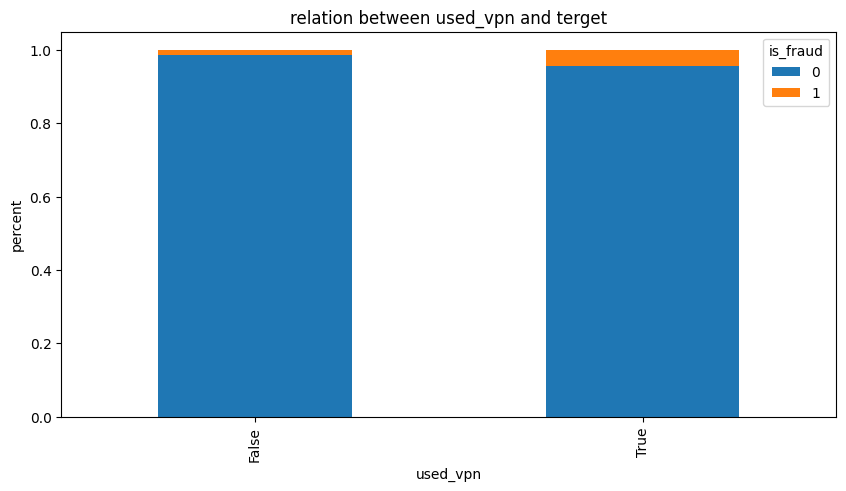

In [33]:
c=pd.crosstab(df['used_vpn'],df['is_fraud'],normalize="index")
p=c.plot(kind="bar",stacked=True,figsize=(10,5))
plt.title("relation between used_vpn and terget")
plt.ylabel("percent")
plt.show()

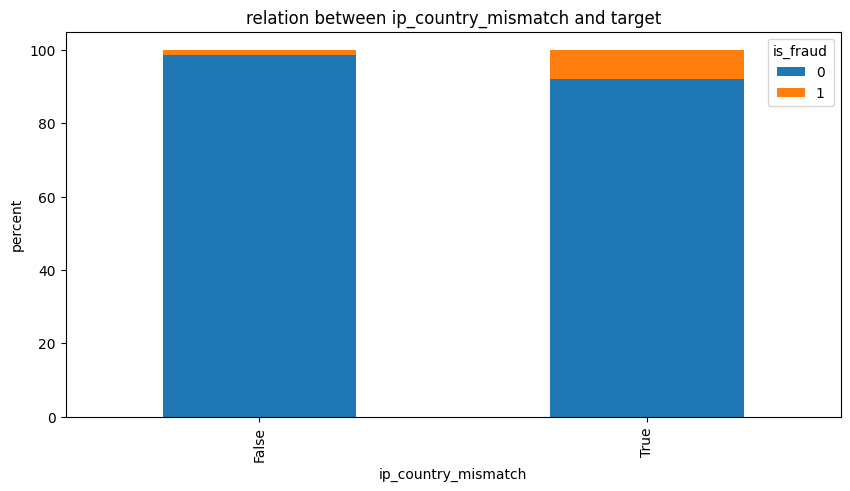

In [34]:
c=pd.crosstab(df['ip_country_mismatch'],df['is_fraud'],normalize="index")
p=c.mul(100).plot(kind="bar",stacked=True,figsize=(10,5))
plt.title("relation between ip_country_mismatch and target")
plt.ylabel("percent")
plt.show()

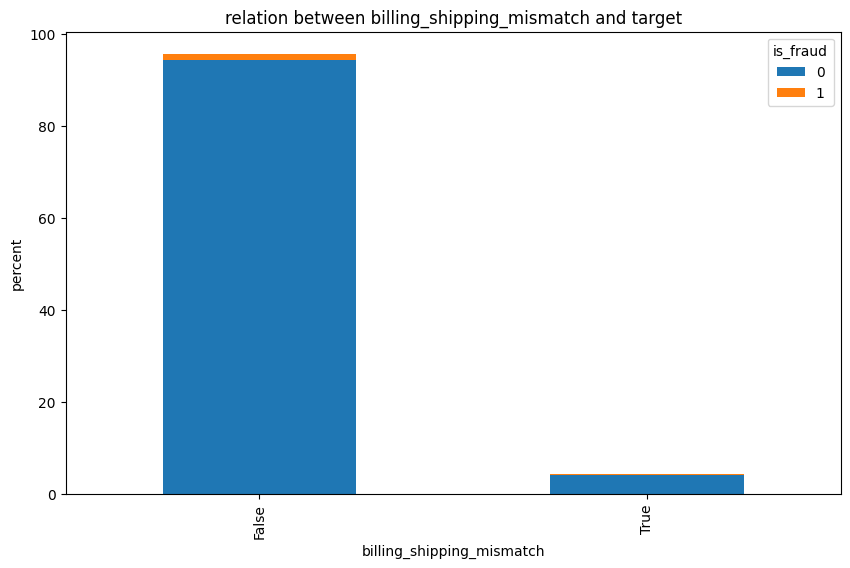

In [35]:
c=pd.crosstab(df['billing_shipping_mismatch'],df['is_fraud'],normalize=True)
p=c.mul(100).plot(kind="bar",stacked=True,figsize=(10,6))
plt.title("relation between billing_shipping_mismatch and target")
plt.ylabel("percent")
plt.show()

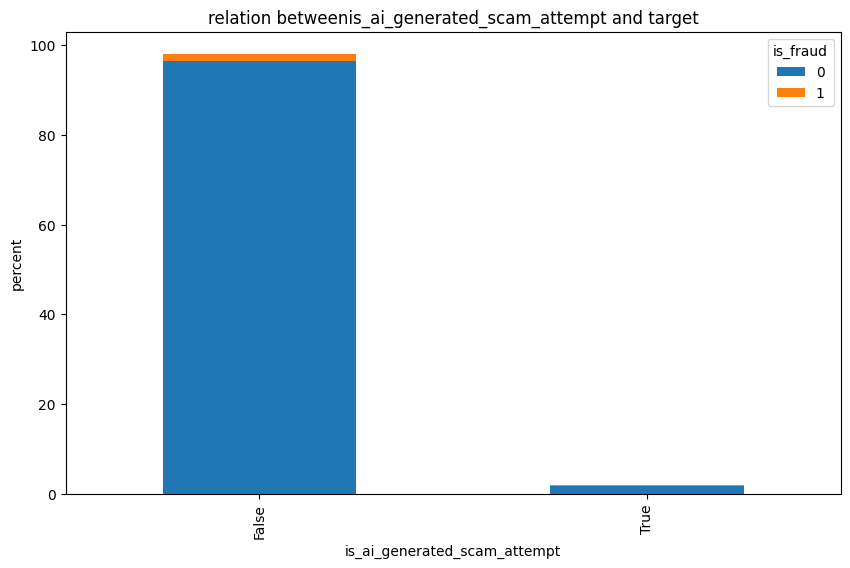

In [36]:
c=pd.crosstab(df['is_ai_generated_scam_attempt'],df['is_fraud'],normalize=True)
p=c.mul(100).plot(kind="bar",stacked="bar",figsize=(10,6))
plt.title("relation betweenis_ai_generated_scam_attempt and target")
plt.ylabel("percent")
plt.show()

# CONVERT BOOL COLUMNS TO NUMERIC

In [37]:
cols=df.select_dtypes(include="bool").columns
df[cols]=df[cols].astype(int)

# correlation

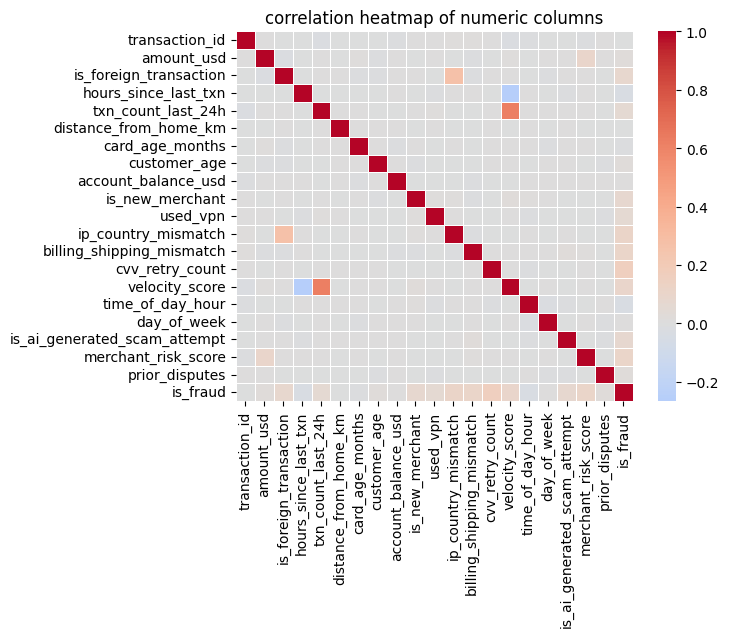

In [38]:
n_df=df.select_dtypes(include="number")
corr=n_df.corr()
sns.heatmap(corr,cmap="coolwarm",center=0,linewidths=0.5)
plt.title("correlation heatmap of numeric columns")
plt.show()

# PREPROCESSING

In [39]:
#droping the id transaction_id columns
df=df.drop('transaction_id',axis=1)

# OUTLIER DETECTION every columns in percentage

In [40]:
num_df=df.select_dtypes(include=["int64","float64"])
q1=num_df.quantile(0.25)
q3=num_df.quantile(0.75)
iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr

outlier=(num_df.lt(lower))|(num_df.gt(upper))

percent=outlier.mean()*100
print(percent.sort_values(ascending=False))

prior_disputes                  24.575
is_new_merchant                 23.005
cvv_retry_count                 16.710
amount_usd                      10.305
used_vpn                         8.795
account_balance_usd              7.845
is_foreign_transaction           6.200
ip_country_mismatch              5.830
hours_since_last_txn             4.775
distance_from_home_km            4.520
billing_shipping_mismatch        4.365
is_ai_generated_scam_attempt     1.875
merchant_risk_score              1.790
is_fraud                         1.695
txn_count_last_24h               1.680
velocity_score                   1.065
card_age_months                  0.885
customer_age                     0.000
day_of_week                      0.000
time_of_day_hour                 0.000
dtype: float64


# CONVERTING CATAGORICAL COLUMNS INTO NUMERICALS

In [41]:
cat=['merchant_category',
'card_type',
'auth_method',
'channel',
'device_type']

df=pd.get_dummies(df,columns=cat,drop_first=True)


In [42]:
cols=df.select_dtypes(include="bool").columns
df[cols]=df[cols].astype(int)

# TRAINING PHASE

In [43]:
#spliting dataset
X=df.drop(columns=['is_fraud'])
y=df['is_fraud']
X_train,X_test,y_train,y_test=train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
print(X_train.shape)
print(y_train.shape)

(16000, 49)
(16000,)


# random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)
pred=rf.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.00      0.00      0.00        68

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.50      4000
weighted avg       0.97      0.98      0.97      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## xgboost

In [46]:
from xgboost import XGBClassifier
xgb=XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train,y_train)
pred = (xgb.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
print(classification_report(y_test,pred))




              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.62      0.07      0.13        68

    accuracy                           0.98      4000
   macro avg       0.80      0.54      0.56      4000
weighted avg       0.98      0.98      0.98      4000

